# Imports

In [1]:
import os
import sys

In [2]:
current_dir =  os.getcwd()
# replace this following line in the path your frank2d files are.
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

In [3]:
parent_dir

'/localhome/home/zgdz996/frank2d'

In [4]:
import matplotlib.pyplot as plt
import time

In [5]:
machine = 'cpu'  # 'npu' or 'gpu'
if machine == 'gpu':
    import cupy as np
    #frank2d
    from frank2d_gpu.frank2d_gpu import Frank2D
    from frank2d_gpu.geometry import Geometry
    from frank2d_gpu.fourier2d_gpu import FourierTransform2D
    from frank2d_gpu.process_vis_gpu import Gridding
    from frank2d_gpu.plot_gpu import Plot
    from frank2d_gpu.constants import rad_to_arcsec, deg_to_rad
    from frank2d_gpu.posterior_optimization_gpu import MAPEstimator

elif machine == 'cpu':
    # frank2d
    import numpy as np

    from frank2d import Frank2D
    from frank2d.geometry import Geometry
    from frank2d.posterior_optimization import *
    from frank2d.constants import rad_to_arcsec, deg_to_rad
    from frank2d.plot import Plot


In [6]:
disc = 'Simulated'

In [7]:
dir = "./../../data/uvtable/"
if disc == 'Simulated':
    data_file = dir + "uvtable_SimulatedBlob.txt"
    inc = 0
    pa = 0
    dra = 0
    ddec = 0
    rout = 1

    file = np.loadtxt(data_file, unpack=True)
    u, v, Im, Re, Weights = file
    Vis = Re + Im*1j

if disc == 'AS209':
    AS209 = {'inc': 34.97, 'pa': 85.76, 'dra':1.9e-3, 'ddec':-2.5e-3, 'rout': 1.2, 'disk_name': 'AS209'}
    data_file = dir +"uvtable_" + disc + "_continuum.npz"

    inc = AS209['inc']
    pa = AS209['pa']
    dra = AS209['dra']
    ddec = AS209['ddec']
    rout = AS209['rout']

    file = np.load(data_file)
    u, v, Re, Im, Weights = file['u'], file['v'], file['Re'], file['Im'], file['w']
    Vis = Re + Im*1j


if disc =='Elias27':
    Elias27 = {'inc': 56.2, 'pa': 118.8, 'dra':-5e-3, 'ddec':-8e-3, 'rout': 1.88, 'disk_name': 'Elias27'}
    data_file = dir +"uvtable_" + disc + "_continuum.npz"
    inc = Elias27['inc']
    pa = Elias27['pa']
    dra = Elias27['dra']
    ddec = Elias27['ddec']
    rout = Elias27['rout']

    file = np.load(data_file)
    u, v, Re, Im, Weights = file['u'], file['v'], file['Re'], file['Im'], file['w']
    Vis = Re + Im*1j

uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights }
geom = Geometry(inc, pa, dra, ddec)

### Run

In [8]:

q = np.hypot(uvtable['u'], uvtable['v'])
q_min = np.min(q)
q_max = np.max(q)

Rmax = 3*rout
import math 
N = math.floor(5* Rmax/rad_to_arcsec * q_max)

print("N =", N)
print("Rmax =", Rmax)

N = 642
Rmax = 3


In [9]:
N

642

In [10]:
frank2d = Frank2D(N, rout)
frank2d.process_vis(uvtable)


===>  Setting gridded data...


In [11]:
initial_guess = {'m': -1, 'logl': 4, 'p' : -1}
Rmax_radian = frank2d.Rmax
MAPEs = MAPEstimator(Rmax_radian)


In [12]:
MAPEs.create_gaussian_model(frank2d.gridded_data)

Fitting the visibilities with Frank2D with 2DFT...


 + Time to preprocess the visibilities: 348.79 seconds


In [73]:
GP =  MAPEs.GaussianModel

In [76]:
ps = [ -3, -2.4, -1.5]
ms = np.linspace(-1, -5, 100)
logl = 4

In [77]:
minus_log_likelihood_array = []
intensity_array = []
logdetS_array = []
logdetD_array = []
jTDj_array = []

In [78]:
for p in ps:
    print(f"============================ p: {p} ============================")
    minus_log_likelihood_array.append([])
    intensity_array.append([])
    logdetS_array.append([])
    logdetD_array.append([])
    jTDj_array.append([])
    for m in ms:
        print(f"    ---------------------------- m: {m}")
        logc = p - 5.6*m
        params = {'m': m, 'c': 10**logc,  'logl': logl}
        minus_log_likelihood = GP.minus_log_posterior(params)
        logdetS, logdetD, jTDj = GP.logdetS, GP.logdetD, GP.jDj
        minus_log_likelihood_array[-1].append(minus_log_likelihood)
        logdetS_array[-1].append(logdetS)
        logdetD_array[-1].append(logdetD)
        jTDj_array[-1].append(jTDj)
        intensity_array[-1].append(GP.sol)
        print(f"            -> (m, log_c):({m}, {logc}) with likelihood: {minus_log_likelihood: 2e}")

    dict_p = {
        'p': p,
        'minus_log_likelihood': minus_log_likelihood_array,
        'intensity': intensity_array,
        'logdetS': logdetS_array,
        'logdetD': logdetD_array,
        'jTDj': jTDj_array
    }

    import pickle
    if p<0:
        path =  dir + disc + f'_frank2d_opt_varyingm_with_pm{np.abs(p)}.pkl'
    else:
        path =  dir + disc + f'_frank2d_opt_varyingm_with_p{p}.pkl'
    with open(path, 'wb') as f:
        pickle.dump(dict_p, f)

============================ p: -3 ============================
    ---------------------------- m: -1.0


            -> (m, log_c):(-1.0, 2.5999999999999996) with likelihood: -3.963695e+06
    ---------------------------- m: -1.0404040404040404
            -> (m, log_c):(-1.0404040404040404, 2.8262626262626265) with likelihood: -2.391952e+06
    ---------------------------- m: -1.0808080808080809
            -> (m, log_c):(-1.0808080808080809, 3.0525252525252524) with likelihood: -2.466230e+06
    ---------------------------- m: -1.121212121212121
            -> (m, log_c):(-1.121212121212121, 3.2787878787878775) with likelihood: -1.087798e+06
    ---------------------------- m: -1.1616161616161615
            -> (m, log_c):(-1.1616161616161615, 3.5050505050505043) with likelihood: -6.139846e+06
    ---------------------------- m: -1.202020202020202
            -> (m, log_c):(-1.202020202020202, 3.731313131313131) with likelihood: -6.895219e+06
    ---------------------------- m: -1.2424242424242424
            -> (m, log_c):(-1.2424242424242424, 3.957575757575757) with likelihood:  1.232

In [17]:
len(minus_log_likelihood_array)

3

### Load

In [18]:

names_p = ['0', '1', 'm1', 'm2', 'm3']

ms = np.linspace(0, -5, 100)

for i in range(len(names_p)):
    path =  dir + disc + f'_frank2d_varyingm_with_p{names_p[i]}.pkl'
    with open(path, 'rb') as f:
        dict_p = pickle.load(f)

        minus_log_likelihood_array = dict_p['minus_log_likelihood'][0]
        intensity_array = dict_p['intensity'][0]
        logdetS_array = dict_p['logdetS'][0]
        logdetD_array = dict_p['logdetD'][0]
        jTDj_array = dict_p['jTDj'][0]

        plt.figure(figsize=(10, 5))
        #plot_change(np.array(minus_log_likelihood_array), label='-log likelihood')
        #plt.plot(ms, p_m3_intensity, label = 'intensity')
        plot_change(np.array(logdetD_array), label='logdetD')
        plot_change(np.array(logdetS_array), marker = 'x', ls= 'None', label='logdetS')
        #plot_change(np.array(jTDj_array), label='jTDj')
        #plt.yscale('log')
        plt.legend()
        #plt.xlim(-2, -5)
        #plt.ylim(-4000, 4000)
        plt.xlabel('m')
        plt.title(r'p($10^5$) =' + f' {dict_p["p"]}')

    

FileNotFoundError: [Errno 2] No such file or directory: './../../data/uvtable/Simulated_frank2d_varyingm_with_p0.pkl'

### Plot

In [79]:
def plot_change(arr, **kwargs):
    plt.plot(ms, np.array(arr)-np.mean(arr), **kwargs)



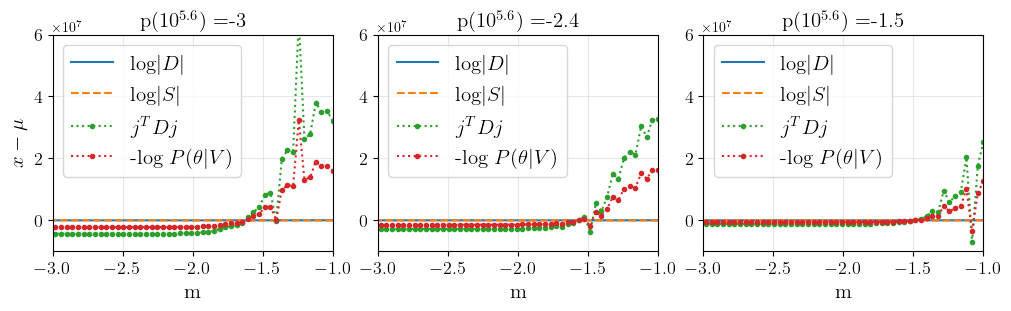

In [84]:
import matplotlib.pyplot as plt
import numpy as np
import math

# 1. Adaptamos tu función para que acepte el eje 'ax'
# Mantenemos 'ms' (variable global) y la resta de la media
def plot_change_sub(ax, arr, **kwargs):
    # Se asume que 'ms' existe globalmente, como en tu código original
    ax.plot(ms, arr - np.mean(arr), **kwargs)

# 2. Configuración de la cuadrícula
n_plots = len(minus_log_likelihood_array)
cols = 3
rows = 1

fig, axes = plt.subplots(rows, cols, figsize=(10, 3), constrained_layout=True)
axes_flat = axes.flatten()

# 3. Iteración
for i, (mll, ldS, ldD, jTdj) in enumerate(zip(minus_log_likelihood_array, 
                                              logdetS_array, 
                                              logdetD_array, 
                                              jTDj_array)):
    
    ax = axes_flat[i]

    mll = np.array(mll)
    ldS = np.array(ldS)
    ldD = np.array(ldD)
    jTdj = np.array(jTdj)
    
    # Llamamos a la función adaptada pasando el eje 'ax'
    plot_change_sub(ax, -ldD, label=r'log$|D|$')
    plot_change_sub(ax, ldS, ls = '--', label=r'log$|S|$')
    plot_change_sub(ax, -jTdj, marker = '.', ls=':', label=r'$j^{T}Dj$')
    plot_change_sub(ax, mll, marker = '.', ls= ':', label=r'-log $P(\theta|V)$')


    ax.legend(fontsize=15, loc='upper left')
    #ax.set_yscale('log')
    ax.set_xlabel('m', fontsize=15)
    ax.set_title(r'p($10^{5.6}$) ='+rf'{ps[i]}', fontsize=15)
    ax.grid(True, alpha=0.3)
    # increase the size of the ticks
    ax.tick_params(axis='both', which='major', labelsize=13)
    ax.set_ylim(-1e7, 6e7)
    ax.set_xlim(-3, -1)

    if i ==0 :
        ax.set_ylabel(r'$x - \mu$', fontsize=15)

# Limpiar ejes vacíos si sobran
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].axis('off')

plt.show()